In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt


In [6]:
# 1.2 Load Movielens dataset (example: 100k dataset)
# Replace 'ratings.csv' with the actual path to your dataset
ratings = pd.read_csv('MovieLens/ratings.csv')

# Preprocess data: Keep only 'userId', 'movieId', and 'rating' columns
ratings = ratings[['userId', 'movieId', 'rating']]
ratings.columns = ['user_id', 'item_id', 'rating']

ratings.head(10)

,user_id,item_id,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
5,1,70,3.0
6,1,101,5.0
7,1,110,4.0
8,1,151,5.0
9,1,157,5.0


In [12]:

# 1.3 Train-test split

if False:
    # Use part of the ratings dataset for training, for faster training
    # (optional, can be removed for full dataset training)
    ratings = ratings.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Split data into train and test sets
# save some data for evaluation
# Split the data into train, test, and evaluation sets
traintest_data, eval_data = train_test_split(ratings, test_size=0.5) #, random_state=42)
train_data, test_data = train_test_split(traintest_data, test_size=0.2) #, random_state=42)

print(test_data.head(20))
print(ratings.shape)

       user_id  item_id  rating
18623      119    49272     5.0
7470        51      719     4.5
12694       80    96917     4.0
12127       74     6858     3.5
97919      606     3668     3.5
16746      105    90405     3.5
38482      264     1917     3.5
99465      608    27839     3.5
31982      219    46335     2.0
79244      491     2716     4.0
54348      357     3095     4.0
77099      482      185     4.0
88809      573     3999     4.0
18258      115     3752     4.0
36380      249       48     3.0
22581      153   117881     3.0
33965      232     1333     1.5
50451      325     5065     2.0
80874      510     1242     3.5
85692      555     2671     4.0
(100836, 3)


In [9]:
# 1.4 Map user and item IDs to indices

# Extract unique users and items
n_users = ratings['user_id'].nunique()
n_items = ratings['item_id'].nunique()
print(f"Number of users: {n_users}, Number of items: {n_items}")
# Create user-item interaction matrix
user_id_map = {user_id: idx for idx, user_id in enumerate(ratings['user_id'].unique())}
item_id_map = {item_id: idx for idx, item_id in enumerate(ratings['item_id'].unique())}

# Map user and item IDs to indices
train_data['user_idx'] = train_data['user_id'].map(user_id_map)
train_data['item_idx'] = train_data['item_id'].map(item_id_map)
test_data['user_idx'] = test_data['user_id'].map(user_id_map)
test_data['item_idx'] = test_data['item_id'].map(item_id_map)
eval_data['user_idx'] = eval_data['user_id'].map(user_id_map)
eval_data['item_idx'] = eval_data['item_id'].map(item_id_map)

train_data.head(10)

Number of users: 610, Number of items: 9724


,user_id,item_id,rating,user_idx,item_idx
58004,380,115149,5.0,379,1078
28996,200,1271,4.0,199,2176
73042,472,3178,4.0,471,2195
15068,96,1089,5.0,95,62
100314,610,58975,3.5,609,9603
20375,135,527,5.0,134,28
32063,220,231,3.5,219,13
80209,504,4246,4.0,503,446
66663,429,48,4.0,428,1400
2177,18,86880,3.0,17,1326


In [10]:
# 1.5 Implementation of Matrix Factorization with SGD


class MatrixFactorization:
    def __init__(self, n_factors=50, learning_rate=0.01, reg_param=0.01, n_epochs=20, use_bias=True, verbose=True):
        """
        Initialize the Matrix Factorization model with optional bias terms.

        Parameters:
        - n_factors: Number of latent factors.
        - learning_rate: Learning rate for SGD.
        - reg_param: Regularization parameter.
        - n_epochs: Number of training epochs.
        - use_bias: Boolean flag to enable or disable bias terms.
        - verbose: Whether to print RMSE at each epoch.
        """
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.reg_param = reg_param
        self.n_epochs = n_epochs
        self.use_bias = use_bias
        self.verbose = verbose
        self.user_factors = None
        self.item_factors = None
        self.user_bias = None
        self.item_bias = None
        self.global_mean = None
        self.errors = []  # List to store RMSE at each epoch
        self.n_users = None
        self.n_items = None 
        self.user_id_map = None
        self.item_id_map = None

    def _initialize_factors(self, n_users, n_items, ratings):
        """
        Initialize user and item latent factors, biases, and global mean.
        """
        self.user_factors = np.random.normal(scale=1.0 / self.n_factors, size=(n_users, self.n_factors))
        self.item_factors = np.random.normal(scale=1.0 / self.n_factors, size=(n_items, self.n_factors))
        if self.use_bias:
            self.user_bias = np.zeros(n_users)
            self.item_bias = np.zeros(n_items)  
            self.global_mean = ratings['rating'].mean()

    def _predict(self, user_id, item_id):
        """
        Predict the rating for a given user and item.
        """
        prediction = np.dot(self.user_factors[user_id], self.item_factors[item_id])
        if self.use_bias:
            prediction += self.global_mean + self.user_bias[user_id] + self.item_bias[item_id]
        return prediction

    def _update_factors(self, user_id, item_id, rating):
        """
        Update user and item latent factors, biases, and global mean using SGD.
        """
        # Compute the prediction error
        prediction = self._predict(user_id, item_id)
        error = rating - prediction

        # Update user and item factors
        self.user_factors[user_id] += self.learning_rate * (error * self.item_factors[item_id] - self.reg_param * self.user_factors[user_id])
        self.item_factors[item_id] += self.learning_rate * (error * self.user_factors[user_id] - self.reg_param * self.item_factors[item_id])

        # Update user and item biases if bias is enabled
        if self.use_bias:
            self.user_bias[user_id] += self.learning_rate * (error - self.reg_param * self.user_bias[user_id])
            self.item_bias[item_id] += self.learning_rate * (error - self.reg_param * self.item_bias[item_id])


    def build_maps(self, data):

        # Extract unique users and items
        self.n_users = data['user_id'].nunique()
        self.n_items = data['item_id'].nunique()
        print(f"Number of users: {self.n_users}, Number of items: {self.n_items}")
        # Create mappings from user/item IDs to indices
        self.user_id_map = {user_id: idx for idx, user_id in enumerate(data['user_id'].unique())}
        self.item_id_map = {item_id: idx for idx, item_id in enumerate(data['item_id'].unique())}



    def fit(self, train_data, test_data, convergence_threshold=1e-4):
        """
        Train the Matrix Factorization model.

        Parameters:
        - train_data: DataFrame with columns ['user_id', 'item_id', 'rating'] for training.
        - test_data: DataFrame with columns ['user_id', 'item_id', 'rating'] for testing.
        """
        # joint train and test data to build maps
        if (self.n_users is None) or (self.n_items is None):
            print("ERROR: run build_maps(all_ratings) before fit()")
            #self.build_maps(pd.concat([train_data, test_data], ignore_index=True))
            return

        # Map user and item IDs to indices
        train_data['user_idx'] = train_data['user_id'].map(self.user_id_map)
        train_data['item_idx'] = train_data['item_id'].map(self.item_id_map)
        test_data['user_idx'] = test_data['user_id'].map(self.user_id_map)
        test_data['item_idx'] = test_data['item_id'].map(self.item_id_map)

        # Initialize latent factors
        self._initialize_factors(self.n_users, self.n_items, train_data)

        # Training loop
        for epoch in range(1, self.n_epochs + 1):
            # Shuffle training data for SGD
            train_data_shuffled = train_data.sample(frac=1).reset_index(drop=True)

            # Update latent factors using SGD
            for _, row in train_data_shuffled.iterrows():
                user_idx = int(row['user_idx'])  # Ensure user_idx is an integer
                item_idx = int(row['item_idx'])  # Ensure item_idx is an integer
                rating = row['rating']  # Rating can remain as float
                self._update_factors(user_idx, item_idx, rating)

            # Compute RMSE on test data
            test_predictions = [
                self._predict(int(user_idx), int(item_idx))
                for _, row in test_data.iterrows()
                for user_idx, item_idx in [(row['user_idx'], row['item_idx'])]
            ]
            test_ratings = test_data['rating'].values
            rmse = np.sqrt(mean_squared_error(test_ratings, test_predictions))
            # previous error
            prev_rmse = self.errors[-1] if self.errors else None
            # Store RMSE for this epoch
            self.errors.append(rmse)  # Store RMSE for this epoch
            # Check for convergence
            if prev_rmse is not None and abs(prev_rmse - rmse)/abs(rmse) < convergence_threshold:
                print(f"Converged at epoch {epoch}.")
                break
            # Check if error is increasing
            if prev_rmse is not None and rmse > prev_rmse:
                print(f"Error increased at epoch {epoch}. Stopping training.")
                break
            if self.verbose:
                print(f"Epoch {epoch}/{self.n_epochs} - Test RMSE: {rmse:.4f}")

    def get_errors(self):
        """
        Return the list of RMSE values at each epoch.
        """
        return self.errors

    def calculate_model_parameters(self):
        """
        Calculate the total number of parameters in the model.
        """
        n_users = self.user_factors.shape[0]
        n_items = self.item_factors.shape[0]

        # Parameters: user_factors, item_factors, user_bias, item_bias, global_mean
        total_params = (
            n_users * self.n_factors  # User latent factors
            + n_items * self.n_factors  # Item latent factors
            + (n_users if self.use_bias else 0)  # User biases
            + (n_items if self.use_bias else 0)  # Item biases
            + (1 if self.use_bias else 0)  # Global mean
        )
        return total_params

    def predict(self, user_id, item_id): #, user_id_map, item_id_map):
        """
        Predict the rating for a given user and item.

        Parameters:
        - user_id: User ID.
        - item_id: Item ID.
        - user_id_map: Mapping from user IDs to indices.
        - item_id_map: Mapping from item IDs to indices.
        """
        user_idx = self.user_id_map[user_id]
        item_idx = self.item_id_map[item_id]
        return self._predict(user_idx, item_idx)




In [15]:
# 1.6 Train the model

# Initialize and train the Matrix Factorization model
mf = MatrixFactorization(n_factors=5, learning_rate=0.01, reg_param=0.01, n_epochs=20, use_bias=False, verbose=True)
mf.build_maps(ratings)

# Train the model
mf.fit(train_data, test_data, convergence_threshold=1e-2)

# Calculate the number of parameters in the model
num_params = mf.calculate_model_parameters()
print(f"Total number of parameters in the model: {num_params}")


Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.6443
Epoch 2/20 - Test RMSE: 3.4573
Epoch 3/20 - Test RMSE: 2.4867
Epoch 4/20 - Test RMSE: 1.9776
Epoch 5/20 - Test RMSE: 1.7342
Epoch 6/20 - Test RMSE: 1.5995
Epoch 7/20 - Test RMSE: 1.5156
Epoch 8/20 - Test RMSE: 1.4594
Epoch 9/20 - Test RMSE: 1.4235
Epoch 10/20 - Test RMSE: 1.3959
Epoch 11/20 - Test RMSE: 1.3773
Epoch 12/20 - Test RMSE: 1.3618
Converged at epoch 13.
Total number of parameters in the model: 51670


In [16]:
# Evaluate the model on the evaluation set
eval_data.describe()

,user_id,item_id,rating
count,50418.000000,50418.000000,50418.000000
mean,326.476854,19408.784541,3.500942
std,182.095561,35400.419870,1.045262
min,1.000000,1.000000,0.500000
25%,177.000000,1198.000000,3.000000
50%,325.000000,2997.000000,3.500000
75%,477.000000,8254.000000,4.000000
max,610.000000,193609.000000,5.000000


In [77]:
# TEST
# mapping of items to indices
print(mf.item_id_map.keys().__len__())
keys = list(mf.item_id_map.keys())
print(keys[0:10])

for i in eval_data['item_id']:
    if i not in keys:
        print("Item not found in item_id_map: ", i)
        break

9724
[np.int64(1), np.int64(3), np.int64(6), np.int64(47), np.int64(50), np.int64(70), np.int64(101), np.int64(110), np.int64(151), np.int64(157)]


In [18]:
# 1.7 Prediction

# Example prediction
# Select one example user and item from the dataset
# Ensure that the user and item IDs exist in the dataset
rating_index = 1000  # Change this to select a different rating


rating_row = ratings.iloc[rating_index]
user_id = rating_row['user_id'].astype(int)  # Ensure user_id is an integer
item_id = rating_row['item_id'].astype(int)  # Ensure item_id is an integer
print(f"User ID: {user_id}, Item ID: {item_id}")


predicted_rating = mf.predict(user_id, item_id) 
print(f"    Predicted rating for user {user_id} and item {item_id}: {predicted_rating:.2f}")

# Actual rating for comparison
actual_rating = rating_row['rating']
error = abs(predicted_rating - actual_rating)
print(f"    Actual rating for user {user_id} and item {item_id}: {actual_rating:.2f}, error: {error:.2f}")

User ID: 7, Item ID: 31878
    Predicted rating for user 7 and item 31878: 2.97
    Actual rating for user 7 and item 31878: 3.50, error: 0.53


In [19]:
# 1.8 Evaluate the model on the evaluation set

# Retrieve RMSE values
errors = mf.get_errors()
print("RMSE per epoch:", errors)


# Compute RMSE on test data
test_predictions = [
    mf.predict(user_id, item_id)
    for _, row in eval_data.iterrows()
    for user_id, item_id in [(row['user_id'], row['item_id'])]
]
test_ratings = eval_data['rating'].values
rmse = np.sqrt(mean_squared_error(test_ratings, test_predictions))

# Print RMSE
print("RMSE on evaluation data: ", rmse)





RMSE per epoch: [3.6443316693127197, 3.4572943082321332, 2.486726016091357, 1.9776130483759515, 1.73415736920165, 1.599497429975308, 1.5155774630418344, 1.4593981980621977, 1.4234698768464906, 1.3958606165144927, 1.3773066733503185, 1.3617515533459401, 1.352558344514945]
RMSE on evaluation data:  1.355474859804254


In [20]:
# Predict values for all data in ratings, and plot the distribution of errors
def predict_errors_plot(input_data, model):
    """
    Predict ratings for the input data using the trained model.
    """
    predictions = input_data.copy()
    predictions['predicted_rating'] = predictions.apply(lambda row: model.predict(row['user_id'], row['item_id']), axis=1)

    # Calculate the error
    predictions['error'] = predictions['predicted_rating'] - predictions['rating']

    # Calculate RMSE for the entire dataset
    rmse_all = np.sqrt(mean_squared_error(predictions['rating'], predictions['predicted_rating']))
    print(f"RMSE error: {rmse_all:.4f}")

    # Plot the distribution of predicted ratings
    fig1 = plt.figure(figsize=(11, 3))
    
    plt.subplot(1, 2, 1)
    
    plt.hist(predictions['predicted_rating'], bins=50, alpha=0.5, color='green')

    # Plot the distribution of actual ratings
    plt.hist(predictions['rating'], bins=50, alpha=0.5, color='red')
    plt.title('Distribution of Actual and Predicted Ratings')
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.grid()
    plt.legend(['Predicted Ratings', 'Actual Ratings'])
    plt.subplot(1, 2, 2)
    
    # Plot the distribution of errors
    #plt.figure(figsize=(8, 3))
    plt.hist(predictions['error'], bins=50, alpha=0.7, color='purple')
    plt.title('Distribution of Prediction Errors, {RMSE: %.4f}' % rmse_all)
    plt.axvline(rmse_all, color='black', linestyle='dashed', linewidth=1)
    plt.axvline(-rmse_all, color='black', linestyle='dashed', linewidth=1)
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()
    
    return predictions


RMSE error: 1.3555


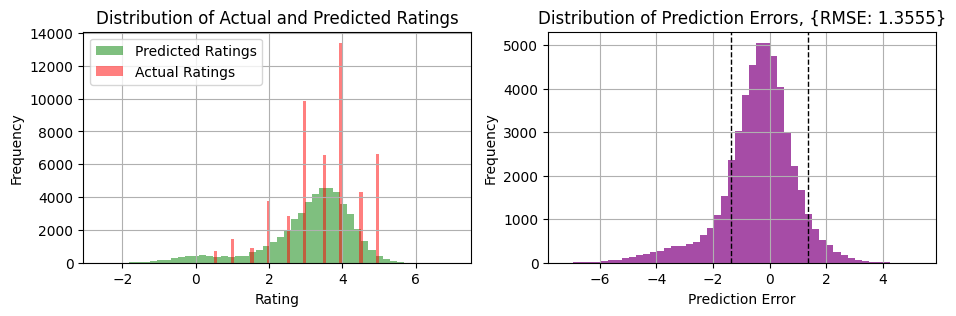

RMSE error: 0.7862


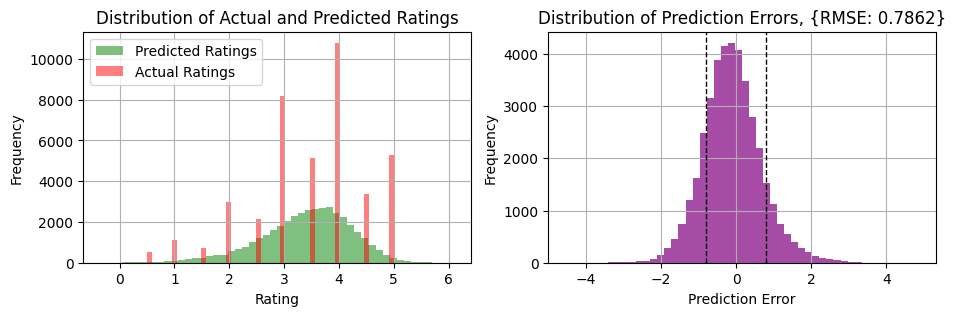

RMSE error: 1.3526


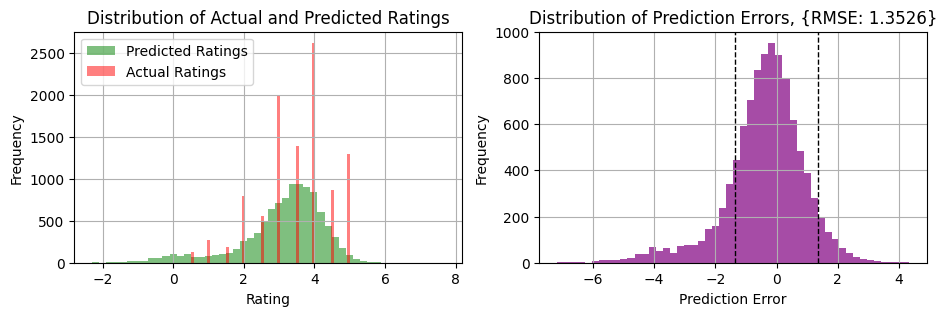

In [22]:
# 1.9 Plot predicted ratings and errors
pre = predict_errors_plot(eval_data, mf)

# train data
pre = predict_errors_plot(train_data, mf)

# test data
pre = predict_errors_plot(test_data, mf)


### 2. Testing models and parameters


 *******    Training with 1 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.6727
Epoch 2/20 - Test RMSE: 3.4570
Epoch 3/20 - Test RMSE: 2.4414
Epoch 4/20 - Test RMSE: 1.9797
Epoch 5/20 - Test RMSE: 1.7625
Epoch 6/20 - Test RMSE: 1.6355
Epoch 7/20 - Test RMSE: 1.5635
Epoch 8/20 - Test RMSE: 1.5118
Epoch 9/20 - Test RMSE: 1.4773
Epoch 10/20 - Test RMSE: 1.4526
Epoch 11/20 - Test RMSE: 1.4339
Epoch 12/20 - Test RMSE: 1.4193
Epoch 13/20 - Test RMSE: 1.4058
Epoch 14/20 - Test RMSE: 1.3976
Epoch 15/20 - Test RMSE: 1.3897
Epoch 16/20 - Test RMSE: 1.3855
Epoch 17/20 - Test RMSE: 1.3836
Epoch 18/20 - Test RMSE: 1.3823
Epoch 19/20 - Test RMSE: 1.3809
Epoch 20/20 - Test RMSE: 1.3803
RMSE error: 1.3934


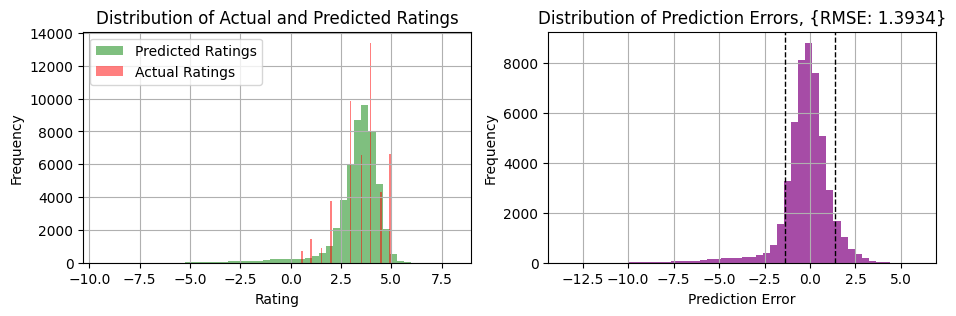

Total number of parameters in the model: 10334

 *******    Training with 2 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.5702
Epoch 2/20 - Test RMSE: 2.2013
Epoch 3/20 - Test RMSE: 1.7149
Epoch 4/20 - Test RMSE: 1.5347
Epoch 5/20 - Test RMSE: 1.4468
Epoch 6/20 - Test RMSE: 1.3968
Epoch 7/20 - Test RMSE: 1.3696
Epoch 8/20 - Test RMSE: 1.3496
Epoch 9/20 - Test RMSE: 1.3352
Epoch 10/20 - Test RMSE: 1.3269
Epoch 11/20 - Test RMSE: 1.3200
Epoch 12/20 - Test RMSE: 1.3160
Error increased at epoch 13. Stopping training.
RMSE error: 1.3329


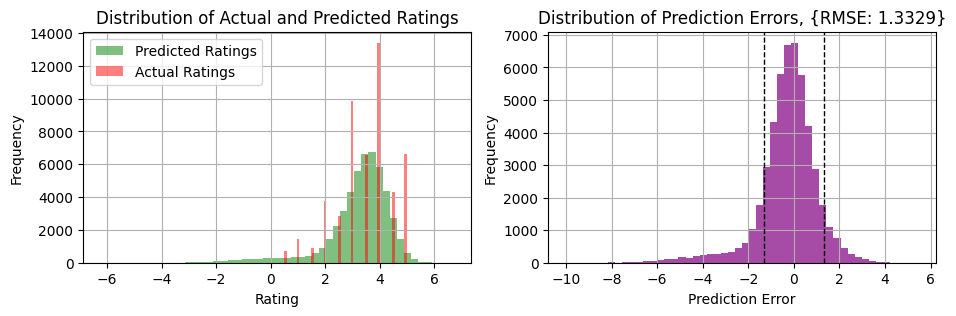

Total number of parameters in the model: 20668

 *******    Training with 5 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.2926
Epoch 2/20 - Test RMSE: 1.8909
Epoch 3/20 - Test RMSE: 1.5569
Epoch 4/20 - Test RMSE: 1.4359
Epoch 5/20 - Test RMSE: 1.3791
Epoch 6/20 - Test RMSE: 1.3501
Epoch 7/20 - Test RMSE: 1.3337
Epoch 8/20 - Test RMSE: 1.3221
Epoch 9/20 - Test RMSE: 1.3176
Epoch 10/20 - Test RMSE: 1.3121
Epoch 11/20 - Test RMSE: 1.3110
Error increased at epoch 12. Stopping training.
RMSE error: 1.3155


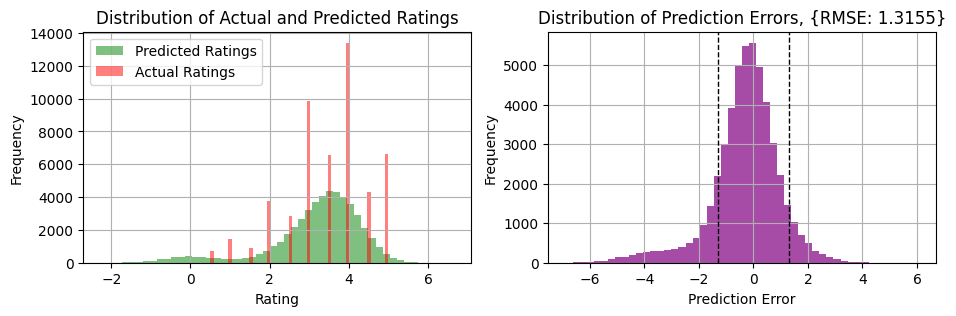

Total number of parameters in the model: 51670

 *******    Training with 10 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.3901
Epoch 2/20 - Test RMSE: 1.9075
Epoch 3/20 - Test RMSE: 1.5494
Epoch 4/20 - Test RMSE: 1.4209
Epoch 5/20 - Test RMSE: 1.3588
Epoch 6/20 - Test RMSE: 1.3312
Epoch 7/20 - Test RMSE: 1.3151
Epoch 8/20 - Test RMSE: 1.3083
Epoch 9/20 - Test RMSE: 1.3075
Epoch 10/20 - Test RMSE: 1.3068
Error increased at epoch 11. Stopping training.
RMSE error: 1.3142


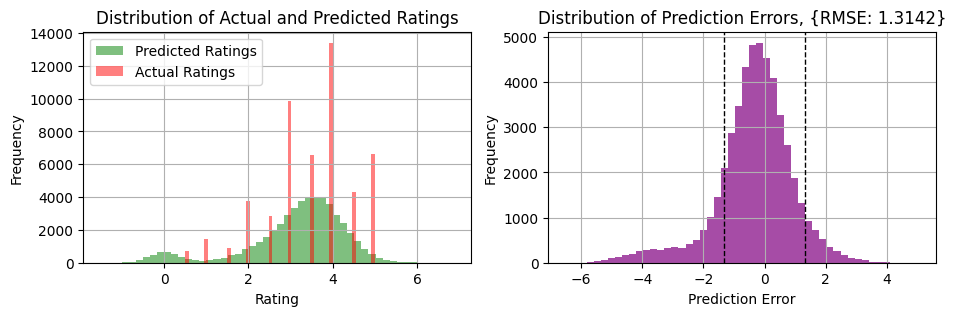

Total number of parameters in the model: 103340

 *******    Training with 30 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.5171
Epoch 2/20 - Test RMSE: 1.9642
Epoch 3/20 - Test RMSE: 1.5598
Epoch 4/20 - Test RMSE: 1.4178
Epoch 5/20 - Test RMSE: 1.3502
Epoch 6/20 - Test RMSE: 1.3181
Epoch 7/20 - Test RMSE: 1.3006
Epoch 8/20 - Test RMSE: 1.2879
Epoch 9/20 - Test RMSE: 1.2843
Epoch 10/20 - Test RMSE: 1.2819
Epoch 11/20 - Test RMSE: 1.2805
Error increased at epoch 12. Stopping training.
RMSE error: 1.2813


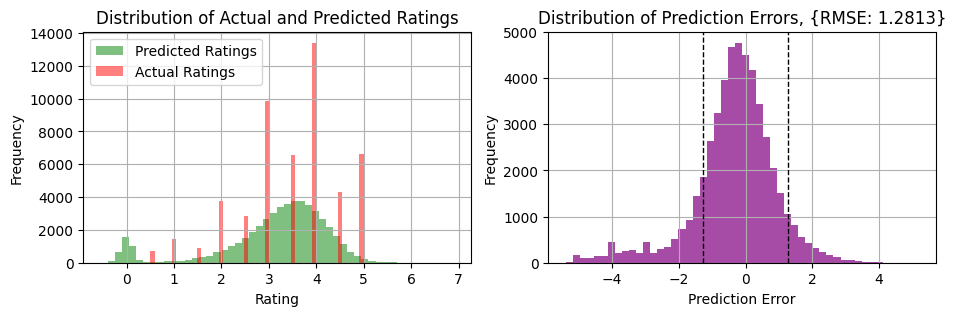

Total number of parameters in the model: 310020

 *******    Training with 50 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.5764
Epoch 2/20 - Test RMSE: 2.0318
Epoch 3/20 - Test RMSE: 1.5773
Epoch 4/20 - Test RMSE: 1.4191
Epoch 5/20 - Test RMSE: 1.3474
Epoch 6/20 - Test RMSE: 1.3125
Epoch 7/20 - Test RMSE: 1.2923
Epoch 8/20 - Test RMSE: 1.2798
Epoch 9/20 - Test RMSE: 1.2736
Epoch 10/20 - Test RMSE: 1.2705
Epoch 11/20 - Test RMSE: 1.2664
Error increased at epoch 12. Stopping training.
RMSE error: 1.2724


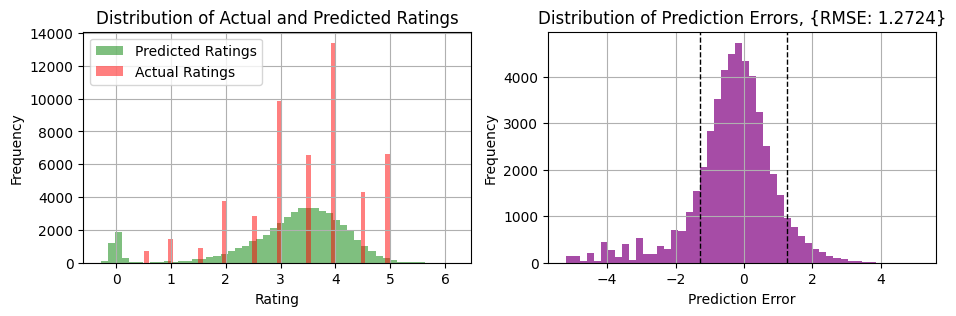

Total number of parameters in the model: 516700


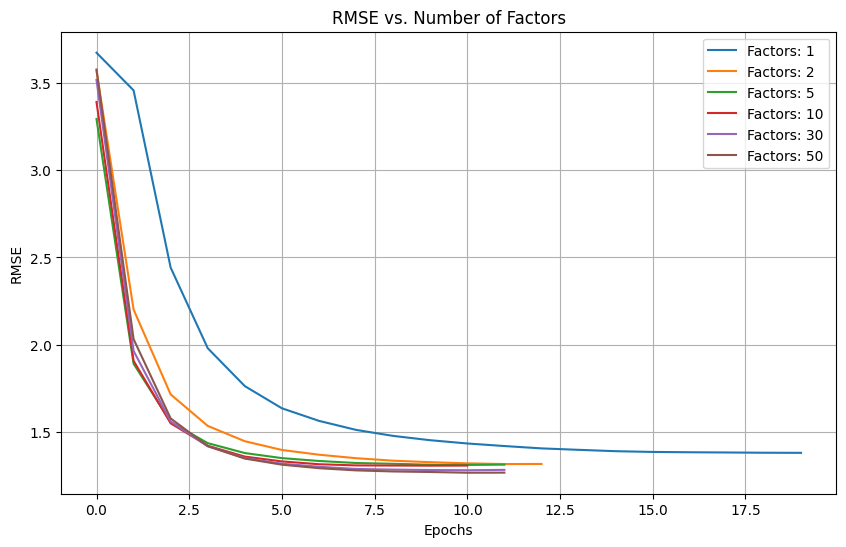

In [23]:
# 2.1 Plot RMSE vs. number of factors

factors_list = [1, 2, 5, 10, 30, 50]

errors_list = []
num_params_list = []

# Train and evaluate the model with different numbers of factors
for n_factors in factors_list:
    
    print(f"\n *******    Training with {n_factors} factors...")
    
    mf = MatrixFactorization(n_factors=n_factors, learning_rate=0.02, reg_param=0.01, n_epochs=20, use_bias=False, verbose=True)
    mf.build_maps(ratings)
    mf.fit(train_data, test_data)
    errors_list.append(mf.get_errors())

    # Evaluate the model on the evaluation set
    predict_errors_plot(eval_data, mf)
    
    # Calculate the number of parameters in the model
    num_params = mf.calculate_model_parameters()
    print(f"Total number of parameters in the model: {num_params}")    
    num_params_list.append(num_params)

# Plot RMSE vs. number of factors
plt.figure(figsize=(10, 6))
for i, n_factors in enumerate(factors_list):
    plt.plot(errors_list[i], label=f'Factors: {n_factors}')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('RMSE vs. Number of Factors')
plt.legend()
plt.grid()
plt.show()



 *******    Training with 1 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9552
Epoch 2/20 - Test RMSE: 0.9240
Epoch 3/20 - Test RMSE: 0.9111
Epoch 4/20 - Test RMSE: 0.9046
Epoch 5/20 - Test RMSE: 0.9002
Epoch 6/20 - Test RMSE: 0.8985
Epoch 7/20 - Test RMSE: 0.8953
Converged at epoch 8.
RMSE error: 0.8963


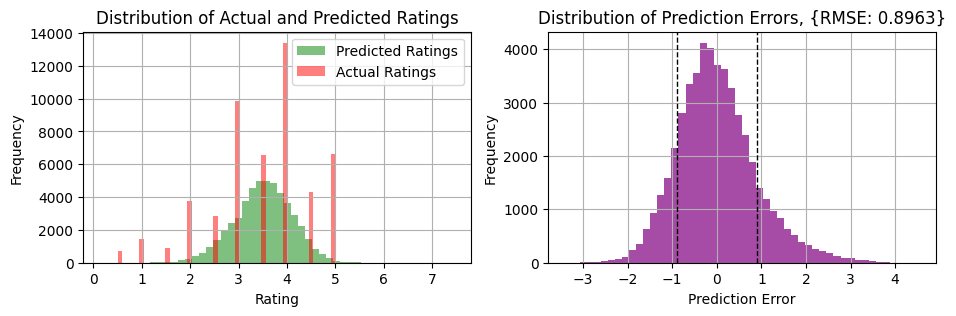

Total number of parameters in the model: 20669

 *******    Training with 2 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9353
Epoch 2/20 - Test RMSE: 0.9150
Epoch 3/20 - Test RMSE: 0.9056
Epoch 4/20 - Test RMSE: 0.9015
Epoch 5/20 - Test RMSE: 0.8982
Error increased at epoch 6. Stopping training.
RMSE error: 0.9012


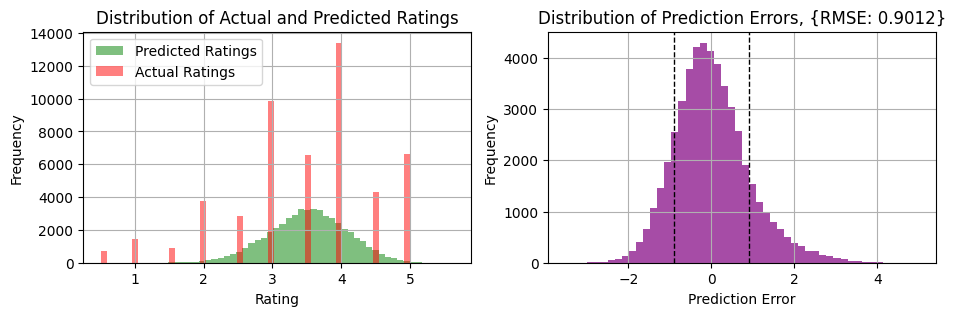

Total number of parameters in the model: 31003

 *******    Training with 5 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9160
Epoch 2/20 - Test RMSE: 0.9028
Epoch 3/20 - Test RMSE: 0.8959
Epoch 4/20 - Test RMSE: 0.8926
Epoch 5/20 - Test RMSE: 0.8911
Error increased at epoch 6. Stopping training.
RMSE error: 0.8950


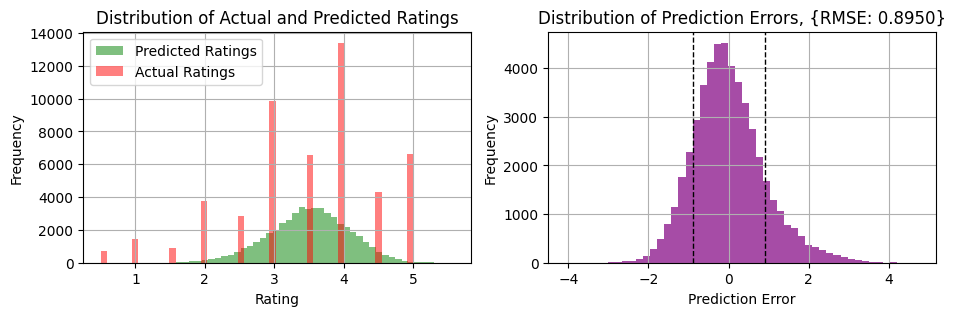

Total number of parameters in the model: 62005

 *******    Training with 10 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9143
Epoch 2/20 - Test RMSE: 0.9000
Epoch 3/20 - Test RMSE: 0.8929
Epoch 4/20 - Test RMSE: 0.8889
Epoch 5/20 - Test RMSE: 0.8870
Epoch 6/20 - Test RMSE: 0.8859
Error increased at epoch 7. Stopping training.
RMSE error: 0.8888


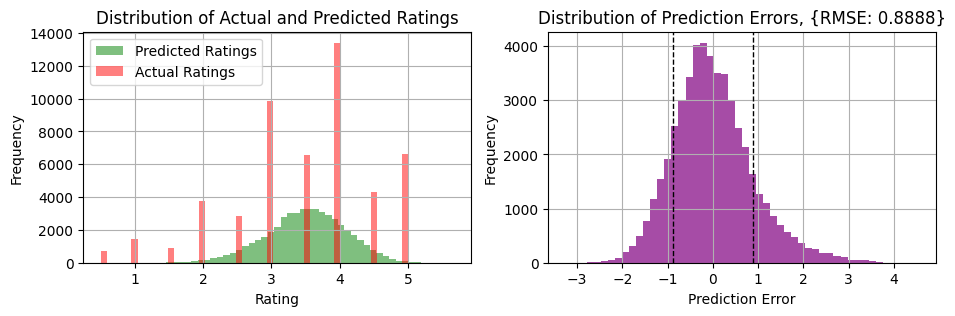

Total number of parameters in the model: 113675

 *******    Training with 30 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9139
Epoch 2/20 - Test RMSE: 0.8997
Epoch 3/20 - Test RMSE: 0.8918
Epoch 4/20 - Test RMSE: 0.8875
Epoch 5/20 - Test RMSE: 0.8846
Epoch 6/20 - Test RMSE: 0.8834
Epoch 7/20 - Test RMSE: 0.8830
Epoch 8/20 - Test RMSE: 0.8801
Error increased at epoch 9. Stopping training.
RMSE error: 0.8832


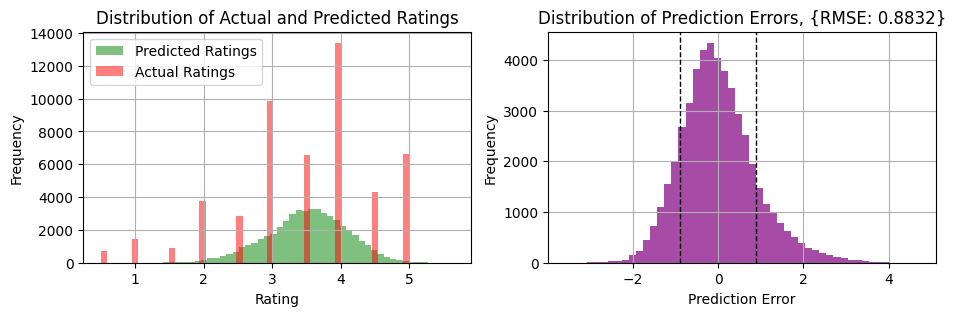

Total number of parameters in the model: 320355

 *******    Training with 50 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9121
Epoch 2/20 - Test RMSE: 0.8990
Epoch 3/20 - Test RMSE: 0.8913
Epoch 4/20 - Test RMSE: 0.8871
Epoch 5/20 - Test RMSE: 0.8869
Epoch 6/20 - Test RMSE: 0.8838
Epoch 7/20 - Test RMSE: 0.8815
Epoch 8/20 - Test RMSE: 0.8814
Epoch 9/20 - Test RMSE: 0.8807
Epoch 10/20 - Test RMSE: 0.8801
Epoch 11/20 - Test RMSE: 0.8798
Converged at epoch 12.
RMSE error: 0.8819


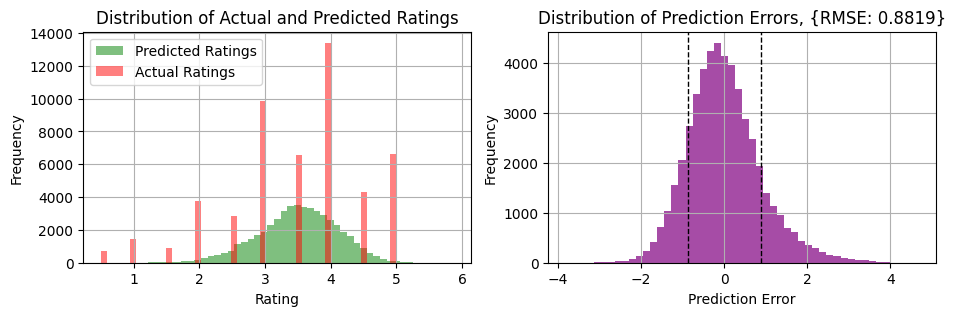

Total number of parameters in the model: 527035


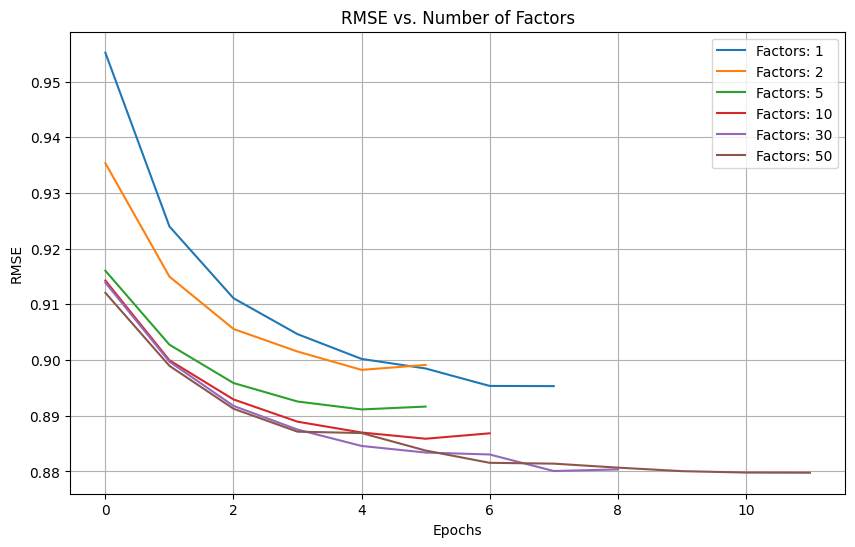

In [24]:
# 2.2. Plot RMSE vs. number of parameters, use Biased model


factors_list = [1, 2, 5, 10, 30, 50]

errors_list = []
num_params_list = []

# Train and evaluate the model with different numbers of factors
for n_factors in factors_list:
    
    print(f"\n *******    Training with {n_factors} factors...")
    
    mf = MatrixFactorization(n_factors=n_factors, learning_rate=0.02, reg_param=0.01, n_epochs=20, use_bias=True, verbose=True)
    mf.build_maps(ratings)
    mf.fit(train_data, test_data)
    errors_list.append(mf.get_errors())

    # Evaluate the model on the evaluation set
    predict_errors_plot(eval_data, mf)
    
    # Calculate the number of parameters in the model
    num_params = mf.calculate_model_parameters()
    print(f"Total number of parameters in the model: {num_params}")    
    num_params_list.append(num_params)

# Plot RMSE vs. number of factors
plt.figure(figsize=(10, 6))
for i, n_factors in enumerate(factors_list):
    plt.plot(errors_list[i], label=f'Factors: {n_factors}')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('RMSE vs. Number of Factors')
plt.legend()
plt.grid()
plt.show()



 *******    Training with 0.002 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9829
Epoch 2/20 - Test RMSE: 0.9603
Epoch 3/20 - Test RMSE: 0.9467
Epoch 4/20 - Test RMSE: 0.9375
Epoch 5/20 - Test RMSE: 0.9308
Epoch 6/20 - Test RMSE: 0.9254
Epoch 7/20 - Test RMSE: 0.9211
Epoch 8/20 - Test RMSE: 0.9176
Epoch 9/20 - Test RMSE: 0.9147
Epoch 10/20 - Test RMSE: 0.9121
Epoch 11/20 - Test RMSE: 0.9099
Epoch 12/20 - Test RMSE: 0.9079
Epoch 13/20 - Test RMSE: 0.9062
Epoch 14/20 - Test RMSE: 0.9046
Epoch 15/20 - Test RMSE: 0.9031
Epoch 16/20 - Test RMSE: 0.9018
Epoch 17/20 - Test RMSE: 0.9005
Epoch 18/20 - Test RMSE: 0.8995
Epoch 19/20 - Test RMSE: 0.8985
Epoch 20/20 - Test RMSE: 0.8976
RMSE error: 0.8982


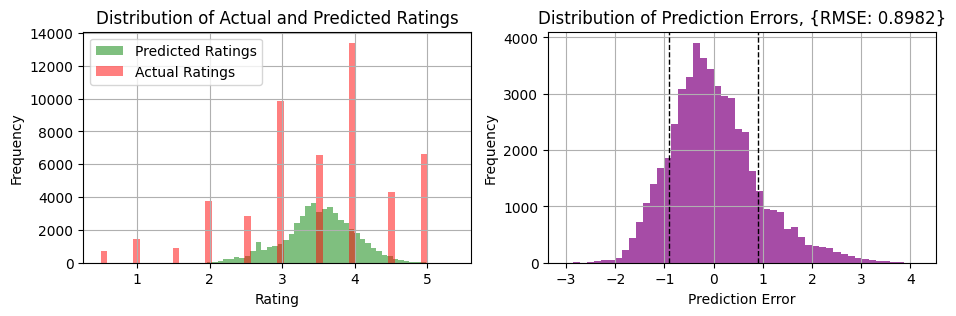

Total number of parameters in the model: 320355

 *******    Training with 0.005 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9526
Epoch 2/20 - Test RMSE: 0.9306
Epoch 3/20 - Test RMSE: 0.9192
Epoch 4/20 - Test RMSE: 0.9121
Epoch 5/20 - Test RMSE: 0.9070
Epoch 6/20 - Test RMSE: 0.9034
Epoch 7/20 - Test RMSE: 0.9000
Epoch 8/20 - Test RMSE: 0.8975
Epoch 9/20 - Test RMSE: 0.8955
Epoch 10/20 - Test RMSE: 0.8936
Epoch 11/20 - Test RMSE: 0.8920
Epoch 12/20 - Test RMSE: 0.8908
Epoch 13/20 - Test RMSE: 0.8900
Epoch 14/20 - Test RMSE: 0.8888
Epoch 15/20 - Test RMSE: 0.8877
Epoch 16/20 - Test RMSE: 0.8868
Epoch 17/20 - Test RMSE: 0.8860
Epoch 18/20 - Test RMSE: 0.8854
Epoch 19/20 - Test RMSE: 0.8847
Epoch 20/20 - Test RMSE: 0.8842
RMSE error: 0.8861


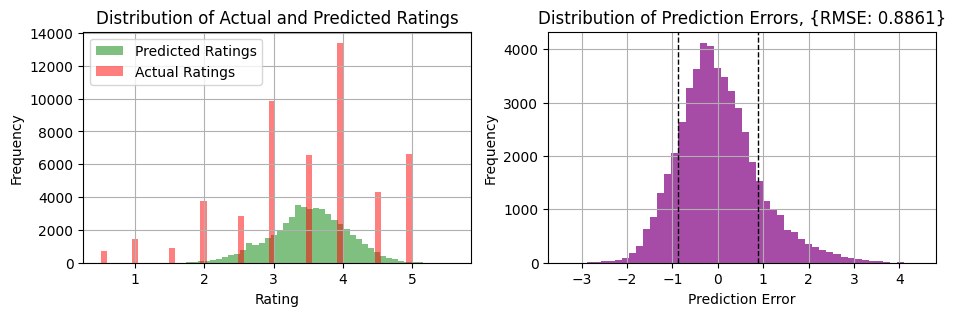

Total number of parameters in the model: 320355

 *******    Training with 0.01 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9302
Epoch 2/20 - Test RMSE: 0.9123
Epoch 3/20 - Test RMSE: 0.9028
Epoch 4/20 - Test RMSE: 0.8974
Epoch 5/20 - Test RMSE: 0.8934
Epoch 6/20 - Test RMSE: 0.8909
Epoch 7/20 - Test RMSE: 0.8890
Epoch 8/20 - Test RMSE: 0.8878
Epoch 9/20 - Test RMSE: 0.8866
Epoch 10/20 - Test RMSE: 0.8851
Epoch 11/20 - Test RMSE: 0.8842
Epoch 12/20 - Test RMSE: 0.8830
Epoch 13/20 - Test RMSE: 0.8824
Error increased at epoch 14. Stopping training.
RMSE error: 0.8846


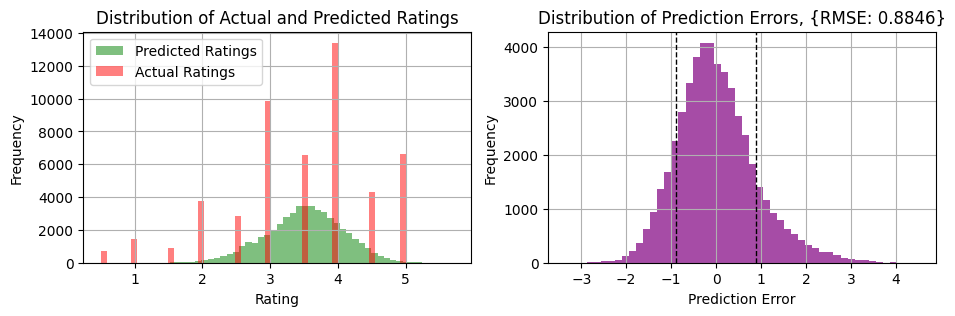

Total number of parameters in the model: 320355

 *******    Training with 0.02 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9128
Epoch 2/20 - Test RMSE: 0.8994
Epoch 3/20 - Test RMSE: 0.8927
Epoch 4/20 - Test RMSE: 0.8891
Epoch 5/20 - Test RMSE: 0.8860
Epoch 6/20 - Test RMSE: 0.8846
Epoch 7/20 - Test RMSE: 0.8829
Epoch 8/20 - Test RMSE: 0.8812
Error increased at epoch 9. Stopping training.
RMSE error: 0.8852


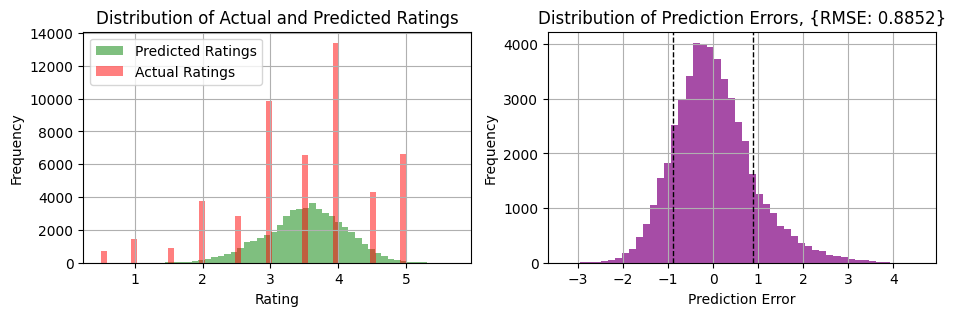

Total number of parameters in the model: 320355

 *******    Training with 0.05 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9015
Epoch 2/20 - Test RMSE: 0.8924
Epoch 3/20 - Test RMSE: 0.8870
Error increased at epoch 4. Stopping training.
RMSE error: 0.8885


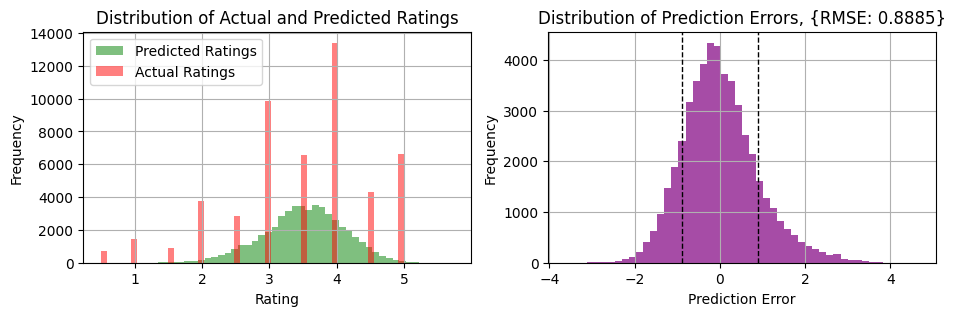

Total number of parameters in the model: 320355


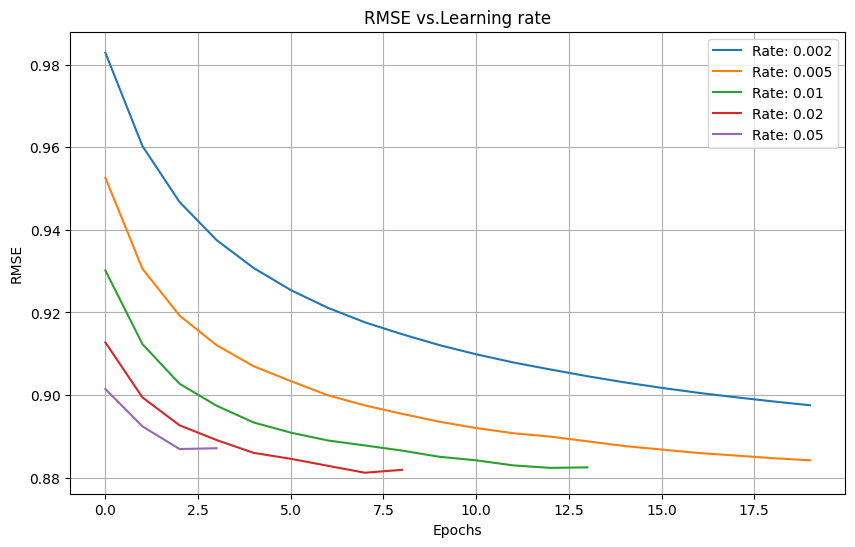

In [25]:
# 2.3. Plot RMSE vs. learning rate
use_bias = True # False
learning_rates = [0.002, 0.005, 0.01, 0.02, 0.05]
n_factors = 30
n_epochs = 50

errors_list = []
num_params_list = []

# Train and evaluate the model with different numbers of factors
for rate in learning_rates:
    
    print(f"\n *******    Training with {rate} learning rate...")
    
    mf = MatrixFactorization(n_factors=n_factors, learning_rate=rate, reg_param=0.01, n_epochs=20, use_bias=True, verbose=True)
    mf.build_maps(ratings)
    mf.fit(train_data, test_data)
    errors_list.append(mf.get_errors())

    # Evaluate the model on the evaluation set
    predict_errors_plot(eval_data, mf)
    
    # Calculate the number of parameters in the model
    num_params = mf.calculate_model_parameters()
    print(f"Total number of parameters in the model: {num_params}")    
    num_params_list.append(num_params)

# Plot RMSE vs. number of factors
plt.figure(figsize=(10, 6))
for i, rate in enumerate(learning_rates):
    plt.plot(errors_list[i], label=f'Rate: {rate}')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('RMSE vs.Learning rate')
plt.legend()
plt.grid()
plt.show()



In [ ]:
# 2.4. Plot RMSE vs. regularization parameter
use_bias = True # False
reg_parameters = [0.001, 0.01, 0.1, 0.2]
n_factors = 30


